# Mall Customer Segmentation using K-Means Clustering

**Name:** Athira V  
**MUID:** athirav-3@mulearn

## Objective

The objective of this project is to segment mall customers into meaningful groups using
K-Means Clustering, an unsupervised machine learning algorithm.

The project includes:
- Data preprocessing
- Exploratory Data Analysis
- Feature scaling
- Elbow Method for selecting the optimal number of clusters
- K-Means clustering
- Cluster profiling
- PCA-based dimensionality reduction
- Customer segment visualization
- Business insights and recommendations

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

**EDA**

**Gender Distribution**

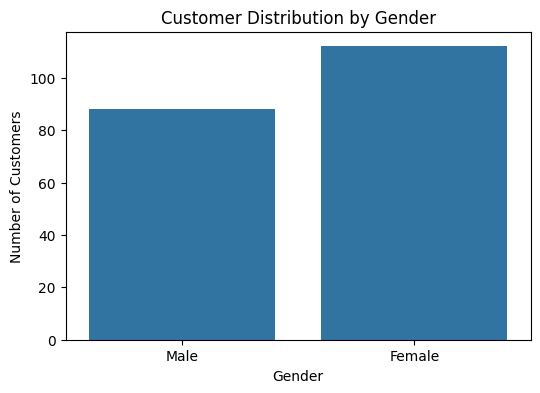

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Gender')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

**Age Distribution**

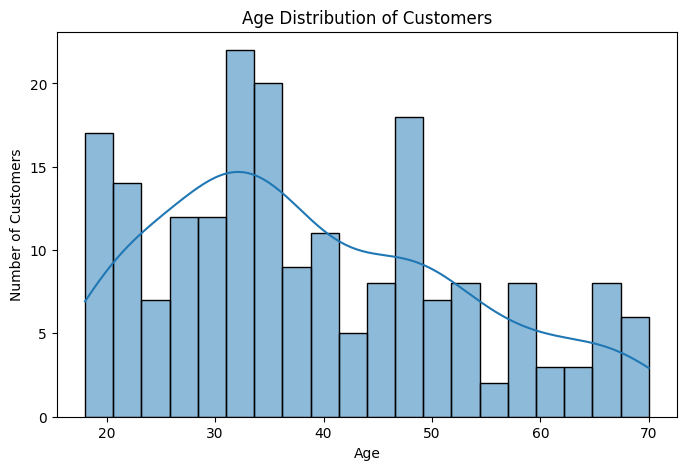

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

**Annual Income Distribution**

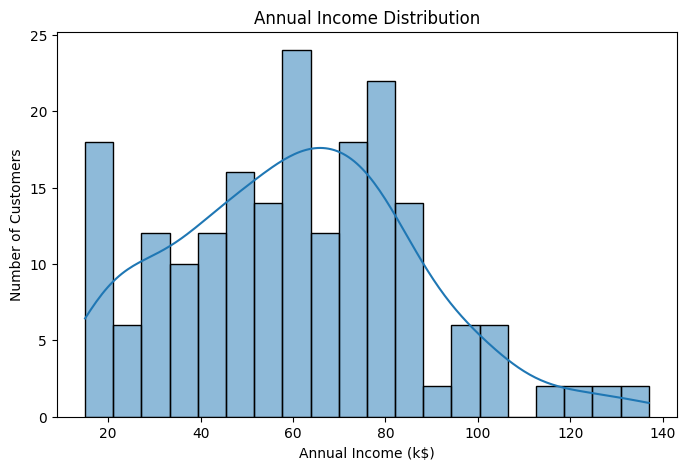

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

**Spending Score Distribution**

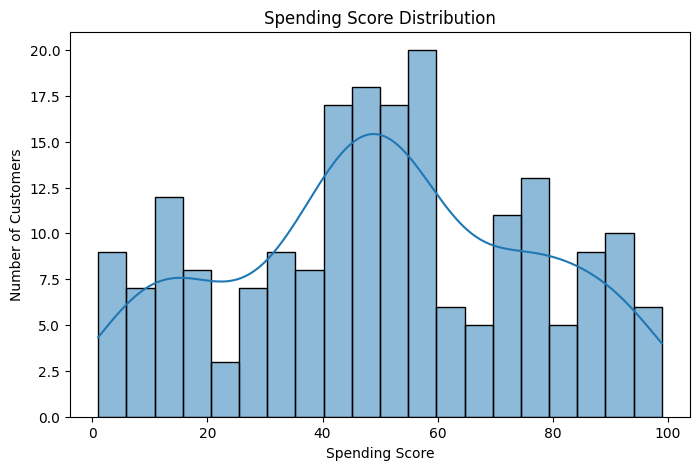

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

**Encode the Categorical Feature**

In [ ]:
df['Gender_Encoded'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [ ]:
df[['Gender', 'Gender_Encoded']].head()

,Gender,Gender_Encoded
0,Male,0
1,Male,0
2,Female,1
3,Female,1
4,Female,1


### Categorical Feature Encoding

The `Gender` column is categorical and cannot be directly used by the K-Means
algorithm. Since it contains only two categories, Male and Female, it was
encoded into numerical values:

- Male → 0
- Female → 1

This allows the feature to be represented numerically for further processing.

**Select Features for Clustering**

In [ ]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)',
    'Gender_Encoded'
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,19,15,39,0
1,21,15,81,0
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,-1.424569,-1.738999,-0.434801,-1.128152
1,-1.281035,-1.738999,1.195704,-1.128152
2,-1.352802,-1.700830,-1.715913,0.886405
3,-1.137502,-1.700830,1.040418,0.886405
4,-0.563369,-1.662660,-0.395980,0.886405


**Find the Optimal Number of Clusters**

In [ ]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

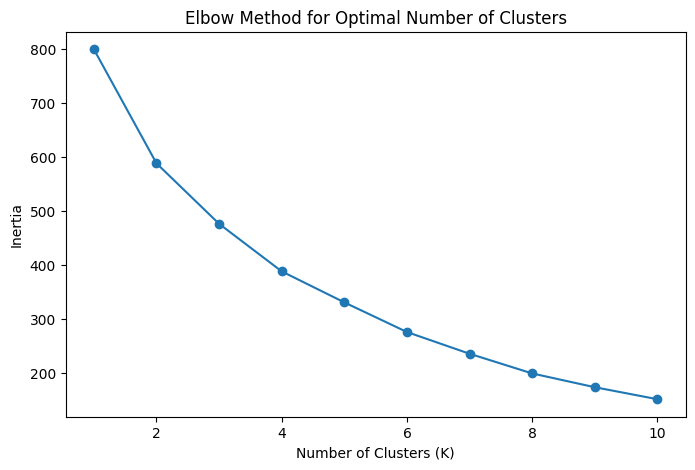

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

**Train the K-Means Model**

In [ ]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,Cluster
0,1,Male,19,15,39,0,3
1,2,Male,21,15,81,0,3
2,3,Female,20,16,6,1,3
3,4,Female,23,16,77,1,3
4,5,Female,31,17,40,1,3


In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,39
1,29
2,43
3,54
4,35


**Visualize Clusters Before PCA**

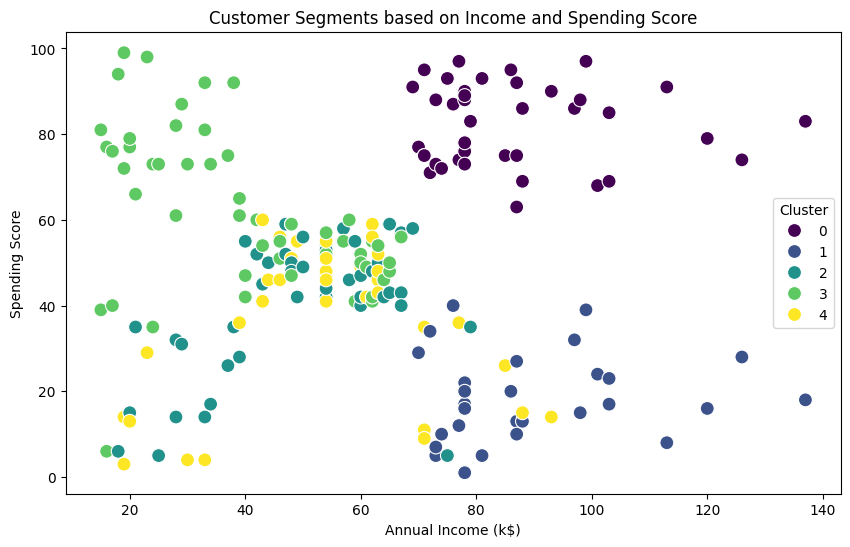

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.show()

**Profile the Clusters**

In [ ]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender_Encoded': 'mean'
}).round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
Cluster,,,,
0,32.69,86.54,82.13,0.54
1,36.48,89.52,18.00,0.55
2,49.81,49.23,40.07,1.00
3,24.91,39.72,61.20,0.59
4,55.71,53.69,36.77,0.00


In [ ]:
cluster_size = df['Cluster'].value_counts().sort_index()

cluster_profile['Customer_Count'] = cluster_size

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,Customer_Count
Cluster,,,,,
0,32.69,86.54,82.13,0.54,39
1,36.48,89.52,18.00,0.55,29
2,49.81,49.23,40.07,1.00,43
3,24.91,39.72,61.20,0.59,54
4,55.71,53.69,36.77,0.00,35


**Give Meaningful Business Names**

In [ ]:
cluster_names = {
    0: 'Budget-Conscious Customers',
    1: 'Premium High-Value Customers',
    2: 'Enthusiastic Shoppers',
    3: 'Careful High-Income Customers',
    4: 'Regular Moderate Spenders'
}

df['Segment'] = df['Cluster'].map(cluster_names)

df[['CustomerID', 'Cluster', 'Segment']].head()

,CustomerID,Cluster,Segment
0,1,3,Careful High-Income Customers
1,2,3,Careful High-Income Customers
2,3,3,Careful High-Income Customers
3,4,3,Careful High-Income Customers
4,5,3,Careful High-Income Customers


**PCA for Dimensionality Reduction**

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['Cluster'].values

pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


**Calculate Explained Variance**

In [ ]:
explained_variance = pca.explained_variance_ratio_

print("PC1 Explained Variance:",
      round(explained_variance[0] * 100, 2), "%")

print("PC2 Explained Variance:",
      round(explained_variance[1] * 100, 2), "%")

print("Total Explained Variance:",
      round(explained_variance.sum() * 100, 2), "%")

PC1 Explained Variance: 33.69 %
PC2 Explained Variance: 26.23 %
Total Explained Variance: 59.92 %


**Visualize PCA Clusters**

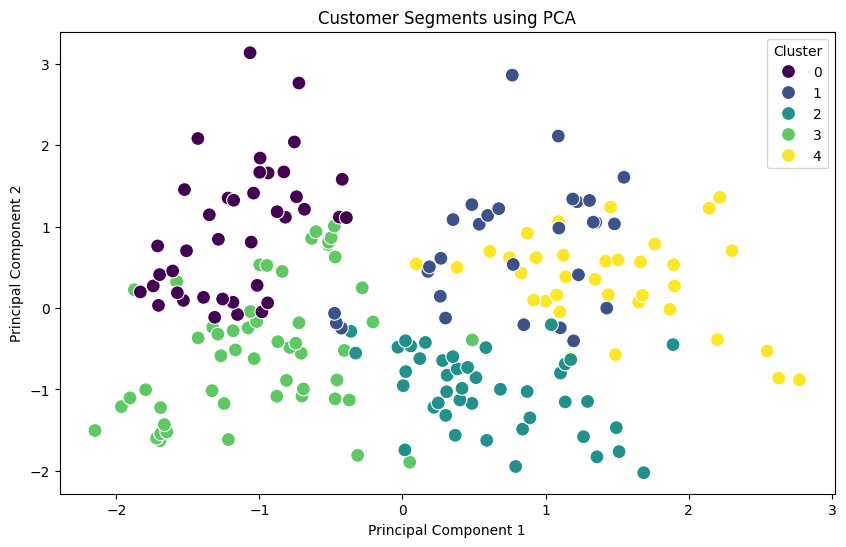

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segments using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

**Create a Final Cluster Summary**

In [ ]:
final_summary = df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

final_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
Segment,,,,
Budget-Conscious Customers,39,32.69,86.54,82.13
Careful High-Income Customers,54,24.91,39.72,61.20
Enthusiastic Shoppers,43,49.81,49.23,40.07
Premium High-Value Customers,29,36.48,89.52,18.00
Regular Moderate Spenders,35,55.71,53.69,36.77


## Business Insights

### 1. Premium High-Value Customers

These customers have relatively high annual income and high spending scores.
They represent the most valuable customer segment.

**Recommended Strategy:**
- Offer premium products and services.
- Provide loyalty rewards.
- Introduce exclusive memberships.
- Use personalized marketing campaigns.
- Provide early access to new products.

### 2. Budget-Conscious Customers

These customers have relatively low income and low spending scores.

**Recommended Strategy:**
- Offer discounts and affordable product bundles.
- Introduce budget-friendly promotions.
- Use seasonal sales to encourage purchases.
- Focus on value-for-money products.

### 3. Enthusiastic Shoppers

These customers have lower or moderate income but relatively high spending
scores.

**Recommended Strategy:**
- Use targeted promotions.
- Offer limited-time discounts.
- Introduce loyalty programs.
- Encourage repeat purchases through personalized recommendations.

### 4. Careful High-Income Customers

These customers have high income but relatively low spending scores.

**Recommended Strategy:**
- Understand the reasons for low engagement.
- Promote premium products.
- Use personalized recommendations.
- Offer exclusive experiences rather than aggressive discounts.

### 5. Regular Moderate Spenders

These customers have moderate income and moderate spending behavior.

**Recommended Strategy:**
- Encourage increased purchase frequency.
- Use loyalty points.
- Provide personalized product recommendations.
- Create cross-selling and upselling opportunities.

## Conclusion

K-Means clustering was successfully used to segment mall customers into
meaningful customer groups based on demographic and behavioral characteristics.

Feature scaling was applied before clustering because K-Means relies on
distance-based calculations. The Elbow Method was used to identify a suitable
number of clusters.

PCA was then applied to reduce the feature space to two dimensions, making it
possible to visualize the customer segments effectively.

The resulting customer segments provide useful insights into customer
behavior. Businesses can use these segments to develop targeted marketing
strategies, improve customer engagement, personalize promotions, and prioritize
high-value customers.

Overall, customer segmentation using unsupervised learning can help businesses
make more data-driven marketing and customer relationship decisions.